<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/src/lunar_SARSA_Deep_QNet.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# SARSA Deep Q-Network en el problema LunarLander-v3

*Description*: Implementación y análisis del algoritmo SARSA Semi-gradiente utilizando aproximación de funciones mediante Redes Neuronales Artificiales para resolver el problema LunarLander-v3.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno


In [ ]:
#@title Copiar el repositorio.
print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
!cd EML_Carrillo_Ibarrola_Palomar/

#@title Importamos todas las clases y funciones
import sys
# Añadir los directorio fuentes al path de Python
sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar')
# Verificar que se han añadido correctamente
print(sys.path)

In [ ]:
# @title Instalación e importación de librerías
# !pip install "gymnasium[box2d]" torch numpy matplotlib tqdm

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

from utils import plot_training_metrics
from agents import SemiGradientSarsaDeepAgent, QNetworkSARSA

import imageio
import base64
from IPython.display import HTML
from collections import deque
# Garantizamos reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Experimento

El experimento evalúa el rendimiento de un agente que utiliza el algoritmo on-policy SARSA Semi-gradiente para aprender a aterrizar el módulo lunar. Este entorno consta de:
- **Espacio de estados**: Vector continuo de 8 dimensiones (coordenadas x/y, velocidades x/y, ángulo, velocidad angular, y contacto de las dos patas).
- **Espacio de acciones**: 4 acciones discretas (0: nada, 1: motor izquierdo, 2: motor principal, 3: motor derecho).
- **Recompensa**: Recompensas basadas en la distancia a la plataforma, velocidad, inclinación, uso de combustible y un premio/castigo final de +100/-100 por aterrizar o estrellarse. El entorno se considera **resuelto** si se alcanzan 200 puntos.

Para más detalles, consultar este [notebook](./lunar_SARSAsemi.ipynb).


## Ejecución del experimento

A diferencia de entornos tabulares como **Taxi-v3**, el espacio de estados de **LunarLander-v3** es **continuo**, lo que hace impracticable utilizar tablas Q explícitas. Por ello, en este experimento se utiliza una **aproximación de la función Q mediante una red neuronal artificial**.

**Objetivo del experimento:**

- Implementar la parametrización de la función de valor de acción $\hat{q}(s, a, \mathbf{w})$ mediante una red neuronal.
- Implementar el bucle de control de SARSA utilizando backpropagation para aproximar el gradiente $\nabla \hat{q}(S, A, \mathbf{w})$.
- Analizar la curva de aprendizaje y la estabilidad del entrenamiento.
- Estudiar la convergencia de la **recompensa media por episodio**.
- Analizar la evolución de la **duración de los episodios**.
- Observar la evolución del **error de entrenamiento de la red (loss)**.
- Comprobar la capacidad del agente para aprender una **política estable de aterrizaje**.
- Estudiar la influencia de hiperparámetros como:
  * tasa de aprendizaje $\alpha$.
  * políticas **epsilon-greedy** y **epsilon-deacaimiento**.
  * tamaño de la red neuronal.
  

La red neuronal utilizada contiene:

* Una capa de entrada de tamaño **8** (dimensión del estado).
* **Dos capas ocultas** de tamaño 128 totalmente conectadas con activación ReLU.
* una capa de salida con **4 neuronas** que representan los valores $Q(s,a)$ para cada acción.

## Entrenamiento

En cada episodio:

1. Se reinicia el entorno y se obtiene el estado inicial.
2. El agente selecciona una acción usando la **política** correspondiente.
3. El entorno devuelve el nuevo estado y la recompensa.
4. Se selecciona la siguiente acción según la política actual (**SARSA**).
5. Se actualizan los parámetros de la red minimizando el error: $\delta = r + \gamma Q(s',a',w) - Q(s,a,w)$
6. Se aplica descenso de gradiente sobre la pérdida cuadrática: $\text{loss} = (Q(s,a,w) - target)^2$
7. Se repite el proceso hasta que el episodio termina.

In [4]:
# @title Bucle de Entrenamiento SARSA Semi-gradiente
def train_sarsa_lunar_lander(agent, episodes=2000):
    scores_window = deque(maxlen=100)  # Cola para calcular la media movil de los ultimos 100
    #rewards_history = []
    env = agent.env
    for t in tqdm(range(episodes)):
        state, info = env.reset(seed=t)  # Reproducibilidad en el estado inicial
        
        action, _ = agent.get_action(state)

        total_reward = 0
        done = False
        
        while not done:
            # # Tomar acción A, observar R, S'
            # action, _ = agent.get_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            # # Elegir A' desde S' usando la política actual
            # next_action = agent.get_action(next_state)
            
            if not done:
                next_action, _ = agent.get_action(next_state)
            else:
                next_action = None  # no se usará si es terminal
            
            # Actualizar pesos: w <- w + alpha * [R + gamma*q(S',A') - q(S,A)] * grad(q)
            # agent.update(state, action, reward, next_state, next_action, done)
            agent.update(
                obs=state,
                action=action,
                reward=reward, # Incremento de reward respecto al frame anterior
                terminated=done,
                next_obs=next_state,
                next_action=next_action
            )

            state = next_state
            action = next_action
            total_reward += reward
            
        agent.decay_epsilon()
        #rewards_history.append(total_reward)
        scores_window.append(total_reward)
        if t % 100 == 0:
            print(f'\rEpisodio {t}\tMedia ultimos 100: {np.mean(scores_window):.2f}')
        
    env.close() 


### $\epsilon$-greedy

In [ ]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 0.05
epsilon_decay = 0
final_epsilon = 0.05
discount_factor = 0.99


env = gym.make("LunarLander-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent = SemiGradientSarsaDeepAgent(
    env=env,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent, episodes=n_episodes)


c:\Users\aaron\miniconda3\envs\dlpln\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
  0%|          | 2/2000 [00:00<04:34,  7.28it/s]

Episodio 0	Media ultimos 100: -82.53


  5%|▌         | 102/2000 [00:10<03:12,  9.88it/s]

Episodio 100	Media ultimos 100: -198.57


 10%|█         | 201/2000 [01:52<28:54,  1.04it/s]  

...

 90%|█████████ | 1801/2000 [36:29<03:50,  1.16s/it]

Episodio 1800	Media ultimos 100: 228.69


 95%|█████████▌| 1901/2000 [38:00<00:25,  3.83it/s]

Episodio 1900	Media ultimos 100: 231.55


100%|██████████| 2000/2000 [39:00<00:00,  1.17s/it]


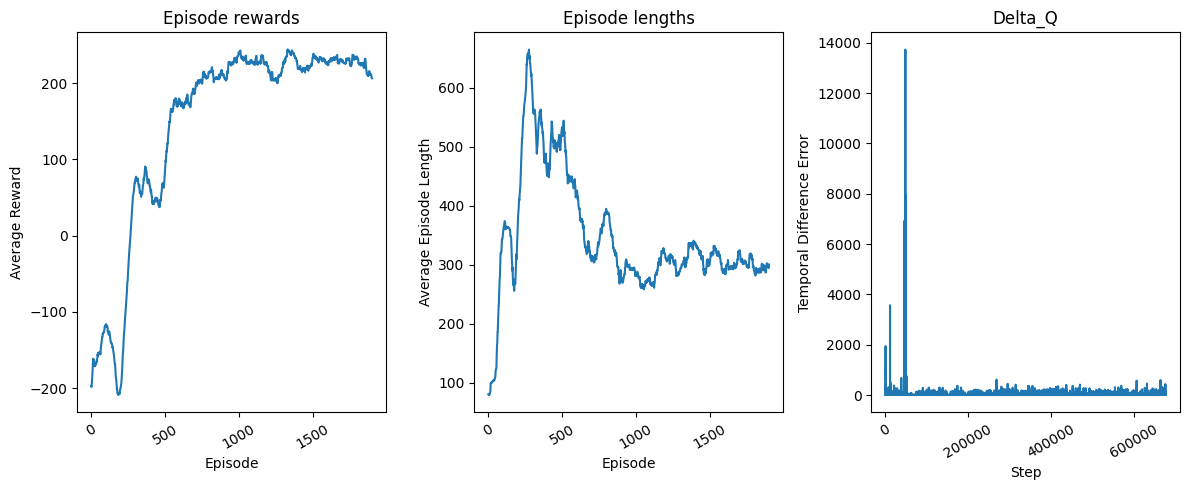

Test Results over 1000 episodes:
Win Rate: 78.9%
Average Reward: 212.304
Standard Deviation: 75.362



In [6]:
plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=100)
agent.test(num_episodes=1000)
print()

### $\epsilon$-greedy otra vez

In [ ]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 0.05
epsilon_decay = 0
final_epsilon = 0.05
discount_factor = 0.99


env = gym.make("LunarLander-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent = SemiGradientSarsaDeepAgent(
    env=env,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent, episodes=n_episodes)

  0%|          | 0/2000 [00:00<?, ?it/s]

Episodio 0	Media ultimos 100: -255.94

  0%|          | 1/2000 [00:00<05:32,  6.01it/s]

  5%|▌         | 101/2000 [00:36<15:02,  2.10it/s]

Episodio 100	Media ultimos 100: -153.06


...

 90%|█████████ | 1801/2000 [38:05<04:09,  1.26s/it]

Episodio 1800	Media ultimos 100: 214.86


 95%|█████████▌| 1901/2000 [40:13<01:34,  1.05it/s]

Episodio 1900	Media ultimos 100: 224.54


100%|██████████| 2000/2000 [41:58<00:00,  1.26s/it]


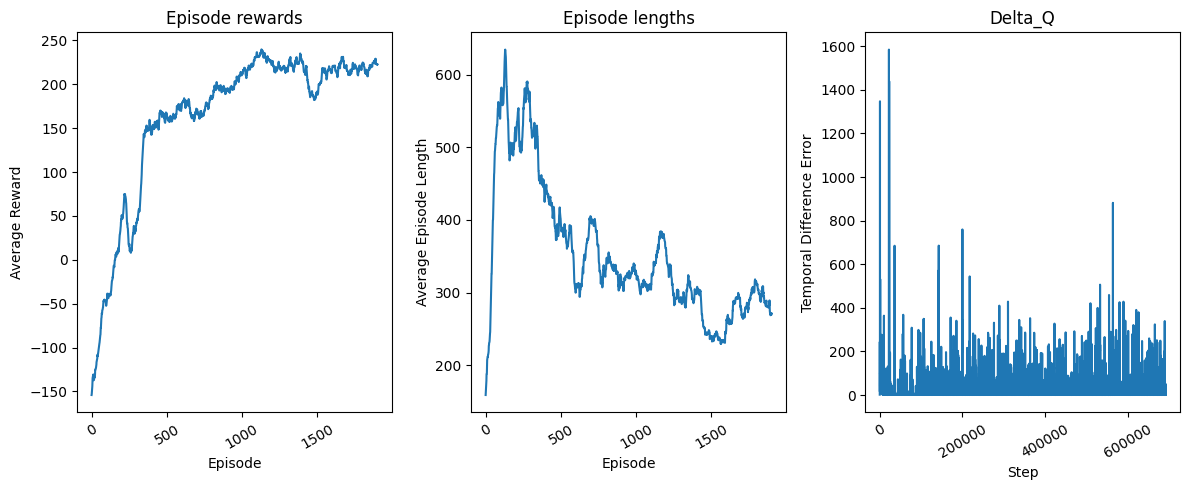

Test Results over 1000 episodes:
Win Rate: 100.0%
Average Reward: 266.405
Standard Deviation: 18.537



In [8]:
plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=100)
agent.test(num_episodes=1000)
print()

### $\epsilon$-decaimiento

In [ ]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.05
discount_factor = 0.99

env2 = gym.make("LunarLander-v3")
env2 = gym.wrappers.RecordEpisodeStatistics(env2, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent2 = SemiGradientSarsaDeepAgent(
    env=env2,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent2, episodes=n_episodes)


  0%|          | 1/2000 [00:00<03:53,  8.56it/s]

Episodio 0	Media ultimos 100: -134.58


  5%|▌         | 102/2000 [00:23<06:07,  5.16it/s]

Episodio 100	Media ultimos 100: -166.89


 10%|█         | 202/2000 [00:49<07:30,  3.99it/s]

...

 90%|█████████ | 1801/2000 [30:50<04:22,  1.32s/it]

Episodio 1800	Media ultimos 100: 211.84


 95%|█████████▌| 1901/2000 [32:28<01:14,  1.32it/s]

Episodio 1900	Media ultimos 100: 206.97


100%|██████████| 2000/2000 [34:09<00:00,  1.02s/it]


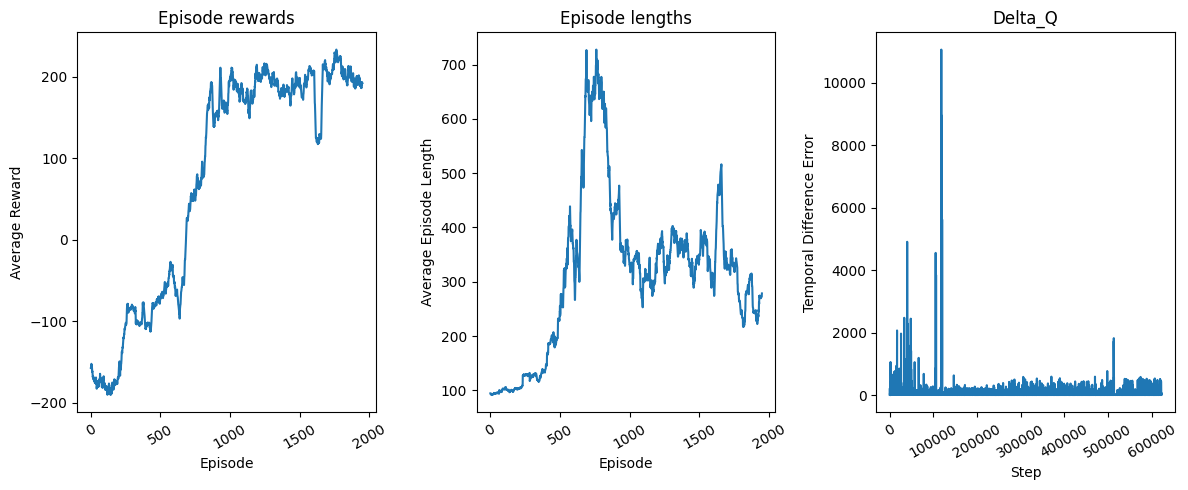

Test Results over 1000 episodes:
Win Rate: 89.7%
Average Reward: 250.575
Standard Deviation: 48.763



In [10]:
plot_training_metrics(env2.return_queue, env2.length_queue, agent2.training_error, rolling_length=50)
agent2.test(num_episodes=1000)
print()

### Learning rate 0.01

In [ ]:
n_episodes = 2000
learning_rate = 0.01
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.05
discount_factor = 0.99

env3 = gym.make("LunarLander-v3")
env3 = gym.wrappers.RecordEpisodeStatistics(env3, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent3 = SemiGradientSarsaDeepAgent(
    env=env3,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent3, episodes=n_episodes)


  0%|          | 1/2000 [00:00<03:58,  8.39it/s]

Episodio 0	Media ultimos 100: -134.58


  5%|▌         | 101/2000 [00:27<10:52,  2.91it/s]

Episodio 100	Media ultimos 100: -177.93


 10%|█         | 202/2000 [00:56<08:44,  3.43it/s]

...

 90%|█████████ | 1801/2000 [24:15<04:42,  1.42s/it]

Episodio 1800	Media ultimos 100: -59.38


 95%|█████████▌| 1901/2000 [26:11<02:03,  1.25s/it]

Episodio 1900	Media ultimos 100: -51.34


100%|██████████| 2000/2000 [29:25<00:00,  1.13it/s]


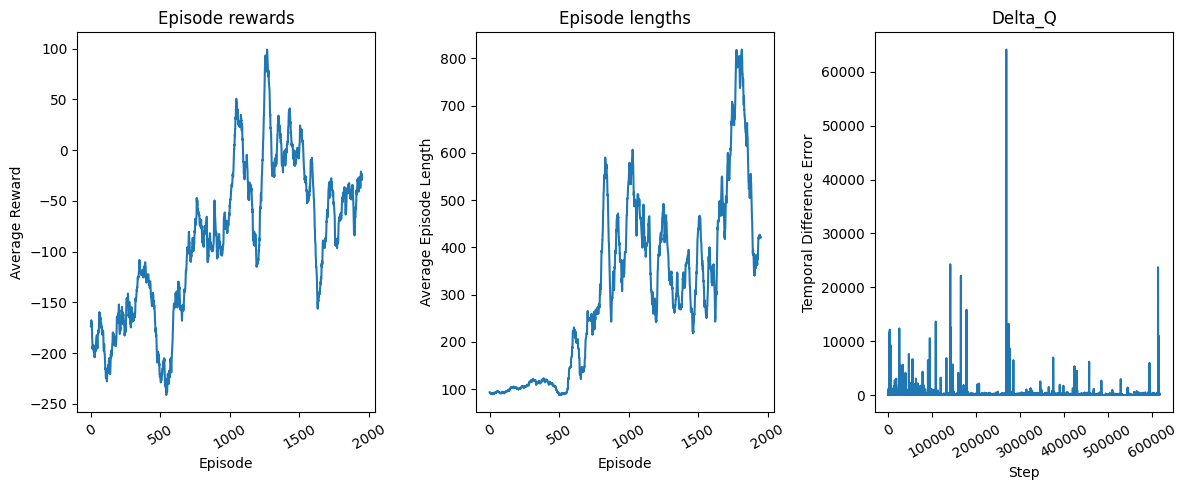

Test Results over 1000 episodes:
Win Rate: 5.3%
Average Reward: -25.482
Standard Deviation: 121.149



In [12]:
plot_training_metrics(env3.return_queue, env3.length_queue, agent3.training_error, rolling_length=50)
agent3.test(num_episodes=1000)
print()

### $\epsilon$-decaimiento, tamaño de capa oculta 64

In [ ]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.05
discount_factor = 0.99

env4 = gym.make("LunarLander-v3")
env4 = gym.wrappers.RecordEpisodeStatistics(env4, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent4 = SemiGradientSarsaDeepAgent(
    env=env4,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
    hidden_dim=64,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent4, episodes=n_episodes)


  0%|          | 1/2000 [00:00<04:22,  7.63it/s]

Episodio 0	Media ultimos 100: -134.58


  5%|▌         | 102/2000 [00:20<05:55,  5.34it/s]

Episodio 100	Media ultimos 100: -184.81


 10%|█         | 202/2000 [00:41<06:30,  4.60it/s]

...

 90%|█████████ | 1802/2000 [19:36<01:32,  2.15it/s]

Episodio 1800	Media ultimos 100: 215.81


 95%|█████████▌| 1901/2000 [20:40<00:49,  1.98it/s]

Episodio 1900	Media ultimos 100: 200.35


100%|██████████| 2000/2000 [21:47<00:00,  1.53it/s]


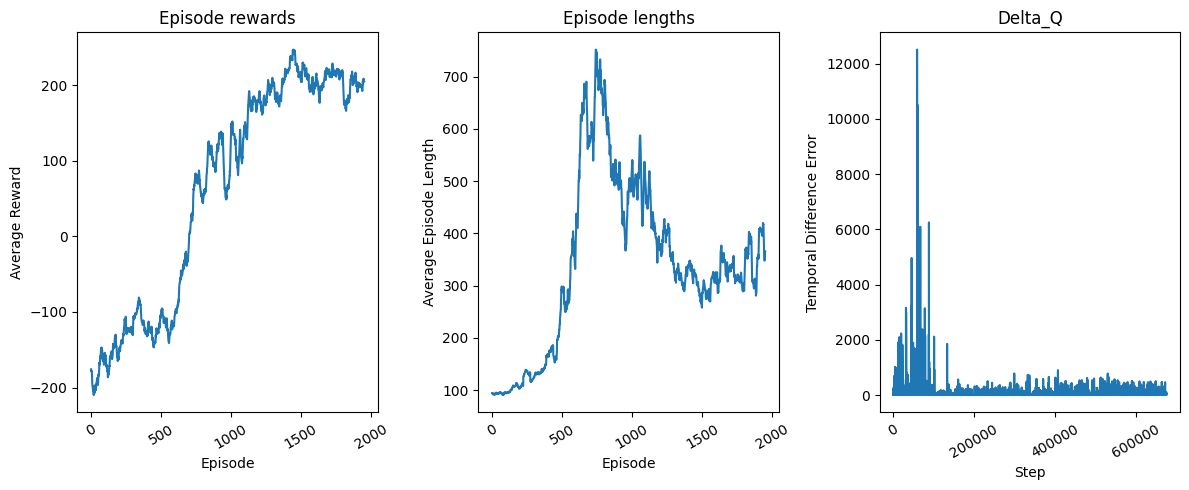

Test Results over 1000 episodes:
Win Rate: 80.0%
Average Reward: 228.271
Standard Deviation: 89.560



In [14]:
plot_training_metrics(env4.return_queue, env4.length_queue, agent4.training_error, rolling_length=50)
agent4.test(num_episodes=1000)
print()

### $\epsilon$-greedy, tamaño de capa oculta 64

In [ ]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 0.05
epsilon_decay = 0
final_epsilon = 0.05
discount_factor = 0.99

env4 = gym.make("LunarLander-v3")
env4 = gym.wrappers.RecordEpisodeStatistics(env4, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent4 = SemiGradientSarsaDeepAgent(
    env=env4,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
    hidden_dim=64,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent4, episodes=n_episodes)


  0%|          | 0/2000 [00:00<?, ?it/s]

Episodio 0	Media ultimos 100: -400.99

  0%|          | 2/2000 [00:00<05:09,  6.46it/s]

  5%|▌         | 101/2000 [00:12<03:52,  8.15it/s]

Episodio 100	Media ultimos 100: -225.06


...

 90%|█████████ | 1801/2000 [22:04<01:31,  2.17it/s]

Episodio 1800	Media ultimos 100: 198.72


 95%|█████████▌| 1901/2000 [23:01<00:57,  1.72it/s]

Episodio 1900	Media ultimos 100: 206.41


100%|██████████| 2000/2000 [23:58<00:00,  1.39it/s]


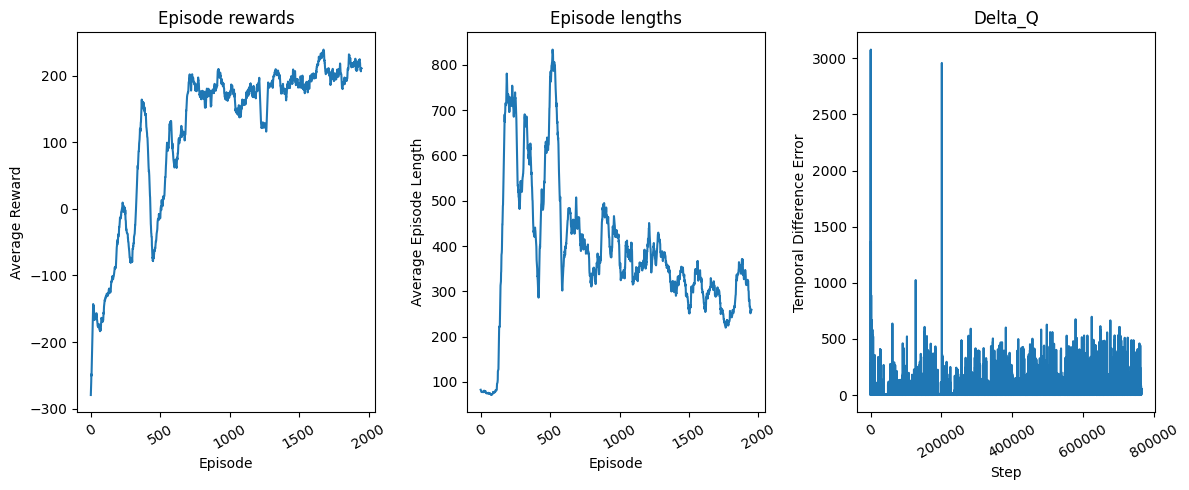

Test Results over 1000 episodes:
Win Rate: 66.9%
Average Reward: 126.326
Standard Deviation: 326.878



In [16]:
plot_training_metrics(env4.return_queue, env4.length_queue, agent4.training_error, rolling_length=50)
agent4.test(num_episodes=1000)
print()

### $\epsilon$-decaimiento, tamaño de capa oculta 32

In [ ]:
n_episodes = 2000
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.05
discount_factor = 0.99

env4 = gym.make("LunarLander-v3")
env4 = gym.wrappers.RecordEpisodeStatistics(env4, buffer_length=n_episodes)  # Para obtener estadísticas de episodios   

agent4 = SemiGradientSarsaDeepAgent(
    env=env4,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
    hidden_dim=32,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent4, episodes=n_episodes)


  0%|          | 0/2000 [00:00<?, ?it/s]

Episodio 0	Media ultimos 100: -134.58


  5%|▌         | 101/2000 [00:12<04:08,  7.66it/s]

Episodio 100	Media ultimos 100: -195.72


 10%|█         | 203/2000 [00:25<03:25,  8.76it/s]

...

 90%|█████████ | 1801/2000 [16:04<02:44,  1.21it/s]

Episodio 1800	Media ultimos 100: 216.70


 95%|█████████▌| 1901/2000 [17:20<01:02,  1.58it/s]

Episodio 1900	Media ultimos 100: 221.99


100%|██████████| 2000/2000 [18:11<00:00,  1.83it/s]


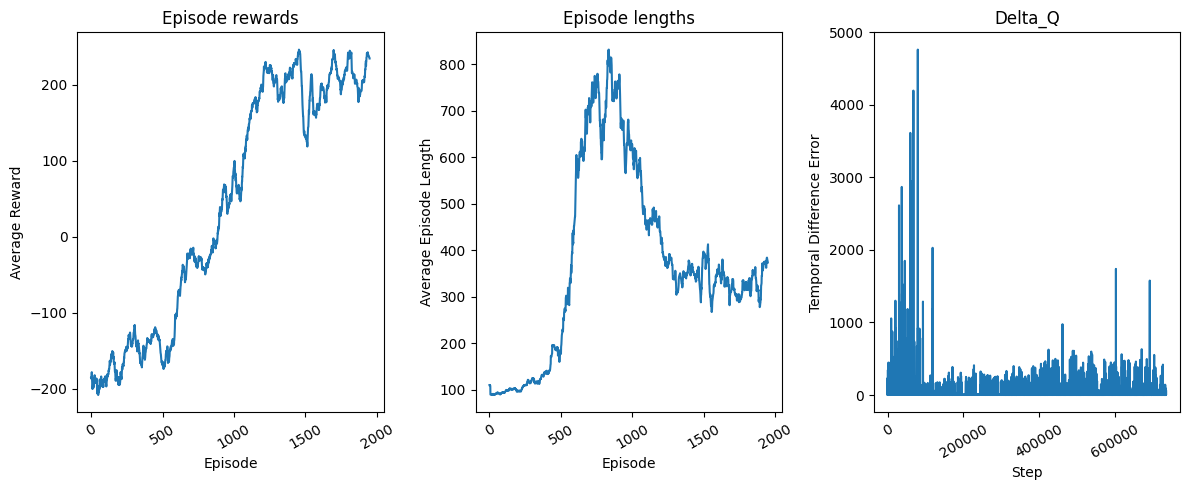

Test Results over 1000 episodes:
Win Rate: 92.4%
Average Reward: 227.560
Standard Deviation: 119.592



In [18]:
plot_training_metrics(env4.return_queue, env4.length_queue, agent4.training_error, rolling_length=50)
agent4.test(num_episodes=1000)
print()

## Análisis de Resultados y Conclusiones

- Recompensa promedio por episodio: Al inicio, el agente obtendrá puntuaciones cercanas a -200 o -300, ya que los motores se activan aleatoriamente y el módulo se estrella rápidamente o sale de la pantalla. 
- A medida que $\epsilon$ decae y los pesos $\mathbf{w}$ se ajustan, la recompensa media aumenta.
- La inestabilidad (gráficas de recompensa que suben a 100 y de repente caen en picado) es una característica de usar Redes Neuronales con métodos on-line como SARSA.
- Las muestras sucesivas $(S, A, R, S')$ están altamente correlacionadas, lo que hace que la red neuronal "olvide" lo aprendido en zonas anteriores del espacio de estados.
- Mientras que en problemas tabulares SARSA y Q-Learning convergen con garantías teóricas, al introducir Redes Neuronales el control del hiperparámetro de tasa de aprendizaje ($\alpha$) y la arquitectura de la red determinan la convergencia. 
- Una mejora es usar DQN (Deep Q-Networks), que añade un "Buffer de Repetición" para romper la correlación y una "Red Objetivo" (Target Network) para estabilizar el gradiente.

In [ ]:
# Guardar pesos del modelo entrenado
torch.save(agent2.q_network.state_dict(), "../data/results/SARSADeepLunarLander/sarsa_lunarlander_qnetwork4.pth")
print("Pesos guardados correctamente.")

Pesos guardados correctamente.


Código sacado de este [repositorio](https://github.com/ldaniel-hm/eml_approximate/blob/0730b02e2a973683f400f71d60e92ac24a403d55/SolucionDeepSARSA_CartPole.ipynb#L345)

In [ ]:
def greedy_action(q_network, state):
    """
    Selecciona la acción óptima (greedy) para un estado dado utilizando la red Q.

    Parámetros:
      - q_network (QNetwork): Red neuronal con los pesos cargados.
      - state: Estado actual del entorno (puede ser una lista o tensor).

    Retorna:
      - int: Acción que maximiza Q(s,a).
    """
    # Desactivamos el cálculo de gradientes (no es necesario en modo evaluación).
    with torch.no_grad():
        # Convertir el estado a tensor si no lo es y añadir dimensión de batch.
        if not isinstance(state, torch.Tensor):
            state = torch.FloatTensor(state).unsqueeze(0)
        # Calcular los valores Q para el estado.
        q_values = q_network(state)
        # Seleccionar la acción que maximiza Q(s,a).
        action = torch.argmax(q_values).item()
    return action

def run_episode_greedy_lunarlander(env, q_network, max_steps=500):
    """
    Ejecuta un episodio usando la política greedy y captura los fotogramas.

    Parámetros:
      - env: Entorno Gymnasium configurado con render_mode='rgb_array'.
      - q_network: Red neuronal QNetwork con los pesos cargados.
      - max_steps (int): Número máximo de pasos a ejecutar en el episodio.

    Retorna:
      - list: Lista de fotogramas (imágenes) capturados durante el episodio.
    """
    frames = []  # Lista para almacenar cada fotograma.

    # Reiniciar el entorno y obtener el estado inicial.
    state, _ = env.reset()
    done = False  # Indicador de finalización del episodio.

    # Ejecutar el episodio hasta max_steps o hasta que el entorno indique que ha terminado.
    for _ in range(max_steps):
        # Capturar el fotograma actual del entorno.
        frame = env.render()
        frames.append(frame)

        # Seleccionar la acción óptima utilizando la función greedy.
        action = greedy_action(q_network, state)

        # Ejecutar la acción en el entorno y obtener el siguiente estado y otros datos.
        next_state, reward, done, truncated, info = env.step(action)
        state = next_state  # Actualizar el estado.

        # Si el episodio ha terminado o se ha truncado, capturar el fotograma final y salir.
        if done or truncated:
            frames.append(env.render())
            break

    return frames

def frames_to_gif(frames, filename="../data/results/SARSADeepLunarLander/lunarlander_sarsa.gif"):
    """
    Crea un archivo GIF a partir de una lista de fotogramas.

    Parámetros:
      - frames (list): Lista de fotogramas (imágenes) capturados del entorno.
      - filename (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Nombre del archivo GIF creado.
    """
    # Abrir un escritor de GIF con imageio.
    with imageio.get_writer(filename, mode='I') as writer:
        # Agregar cada fotograma al GIF.
        for frame in frames:
            writer.append_data(frame)
    return filename
     

def display_gif(gif_path):
    """
    Muestra un GIF en Google Colab.

    Parámetros:
      - gif_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML que contiene el GIF incrustado.
    """
    # Abrir el archivo GIF en modo binario.
    with open(gif_path, 'rb') as f:
        video = f.read()
    # Convertir el contenido del GIF a una cadena Base64.
    b64 = base64.b64encode(video)
    # Retornar el objeto HTML que muestra el GIF.
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

GIF guardado en: results/SARSADeepLunarLander/lunarlander_sarsa.gif



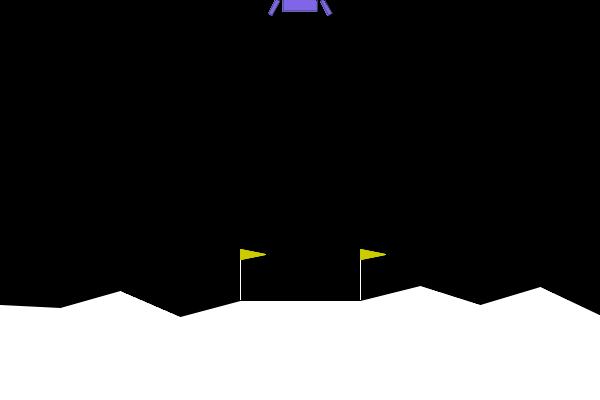

In [ ]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')

state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Crear una instancia de la red QNetwork.
q_net_loaded = QNetworkSARSA(state_dim, action_dim, hidden_dim=128)

# Cargar pesos
q_net_loaded.load_state_dict(torch.load("../data/results/SARSADeepLunarLander/sarsa_lunarlander_qnetwork.pth"))

# Poner la red en modo evaluación para asegurar que se comporta correctamente en inferencia.
q_net_loaded.eval()

# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy_lunarlander(env_demo, q_net_loaded)

# Cerrar el entorno una vez terminado el episodio.
env_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="../data/results/SARSADeepLunarLander/lunarlander_sarsa.gif")
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)